# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** November 7, 2025 <br>
**Objective:** Predict a categorical target and evaluate performance of Decision Tree, Support Vector Machine and Neural Network classifiers.


## Introduction
In this project, we use the Titanic dataset to build and evaluate three classifiers: Decision Tree, Support Vector Machine, and Neural Network. We compare model performance across three different feature sets and reflect on their effectiveness for predicting passenger survival.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [63]:
from imblearn.over_sampling import SMOTE
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from stats_jordan import classification_table


## Section 1. Load and Inspect the Data

Next, we load the Titanic dataset from seaborn and view its head.

In [64]:
titanic_df: pd.DataFrame = sns.load_dataset("titanic")
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Section 2. Data Exploration and Preparation

### 2.1 Handle Missing Values and Clean Data

We impute missing values for 'age' using the median.

In [65]:
median_age = titanic_df["age"].median()
titanic_df["age"] = titanic_df["age"].fillna(median_age)

### 2.2 Feature Engineering

Now, we add the feature 'family_size', number of family members on board, by counting sibsp (number of siblings or spouses on board), parch (number of parents or children on board), and 1 to count the individual. 

In [66]:
titanic_df["family_size"] = titanic_df["sibsp"] + titanic_df["parch"] + 1

Then, we numericaly encode the categorical feature 'alone'.

In [67]:
titanic_df["alone"] = titanic_df["alone"].astype(int)

## Section 3. Feature Selection and Justification

### 3.1  Choose Features and Target

With classification in mind, we now select input and target features for our model.  We will consider the following three different cases for our models:

Case 1: 
- Input Feature: 'alone'
- Target: 'survived'

Case 2:
- Input Feature: 'age'
- Target: 'survived'

Case 3:
- Input Features: 'age' and 'family_size' 
- Target: 'survived'

### 3.2 Define X (features) and y (target)

Now, we define our prediction and target features.

In [68]:
# Case 1: Feature = 'alone'
X1 = titanic_df[["alone"]]
y1 = titanic_df["survived"]

# Case 2: Feature = 'age'
X2 = titanic_df[["age"]].dropna()
y2 = titanic_df.loc[X2.index, "survived"]

# Case 3: Features = 'age' + 'family_size'
X3 = titanic_df[["age", "family_size"]].dropna()
y3 = titanic_df.loc[X3.index, "survived"]

Reflection 3:

1)  Why are these features selected?<br>
   
    The input features of 'alone', 'age', and 'family_size' were selected due initial data exploration performed in Project 2 indicated a strong statistical correlation with our target variable 'survived'.<br><br>
2)  Are there features that are likely to be highly predictive of survival?<br>
   
     Historicaly, when the Titanic began to sink, people of younger age, familys, and women were prioritized for boarding the lifeboats.  Thus, the selected predicting features of 'age', 'alone', and 'family_size' are likely to be highly predictive of the target feature 'survival'.

## Section 4. Train a Classification Model (Decision Tree)
### 4.1 Split the Data

First, we split our data for each case, using a random stratified shuffle split to ensure that both the training and test sets have a similar proportion of each class of our target feature.

In [69]:
# Case 1: Feature = 'alone'
splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx1, test_idx1 in splitter1.split(X1, y1):
    X1_train = X1.iloc[train_idx1]
    X1_test  = X1.iloc[test_idx1]
    y1_train = y1.iloc[train_idx1]
    y1_test  = y1.iloc[test_idx1]

print("Case 1 - 'alone':")
print("Train size:", len(X1_train), "| Test size:", len(X1_test))

# Case 2: Feature = 'age'
splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx2, test_idx2 in splitter2.split(X2, y2):
    X2_train = X2.iloc[train_idx2]
    X2_test  = X2.iloc[test_idx2]
    y2_train = y2.iloc[train_idx2]
    y2_test  = y2.iloc[test_idx2]

print("\nCase 2 - 'age':")
print("Train size:", len(X2_train), "| Test size:", len(X2_test))

# Case 3: Features = 'age' + 'family_size'
splitter3 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx3, test_idx3 in splitter3.split(X3, y3):
    X3_train = X3.iloc[train_idx3]
    X3_test  = X3.iloc[test_idx3]
    y3_train = y3.iloc[train_idx3]
    y3_test  = y3.iloc[test_idx3]

print("\nCase 3 - 'age' + 'family_size':")
print("Train size:", len(X3_train), "| Test size:", len(X3_test))

Case 1 - 'alone':
Train size: 712 | Test size: 179

Case 2 - 'age':
Train size: 712 | Test size: 179

Case 3 - 'age' + 'family_size':
Train size: 712 | Test size: 179


### 4.2 Create and Train Model (Decision Tree)

Now, we create and train a decision tree model with no random initializer argument.

In [70]:
# CASE 1: Decision Tree using 'alone'
tree_model1 = DecisionTreeClassifier()
tree_model1.fit(X1_train, y1_train)

# CASE 2: Decision Tree using 'age'
tree_model2 = DecisionTreeClassifier()
tree_model2.fit(X2_train, y2_train)

# CASE 3: Decision Tree using 'age' and 'family_size'
tree_model3 = DecisionTreeClassifier()
tree_model3.fit(X3_train, y3_train);

### 4.3 Predict and Evaluate Model Performance

At this stage, we predict and evaluate all three cases.

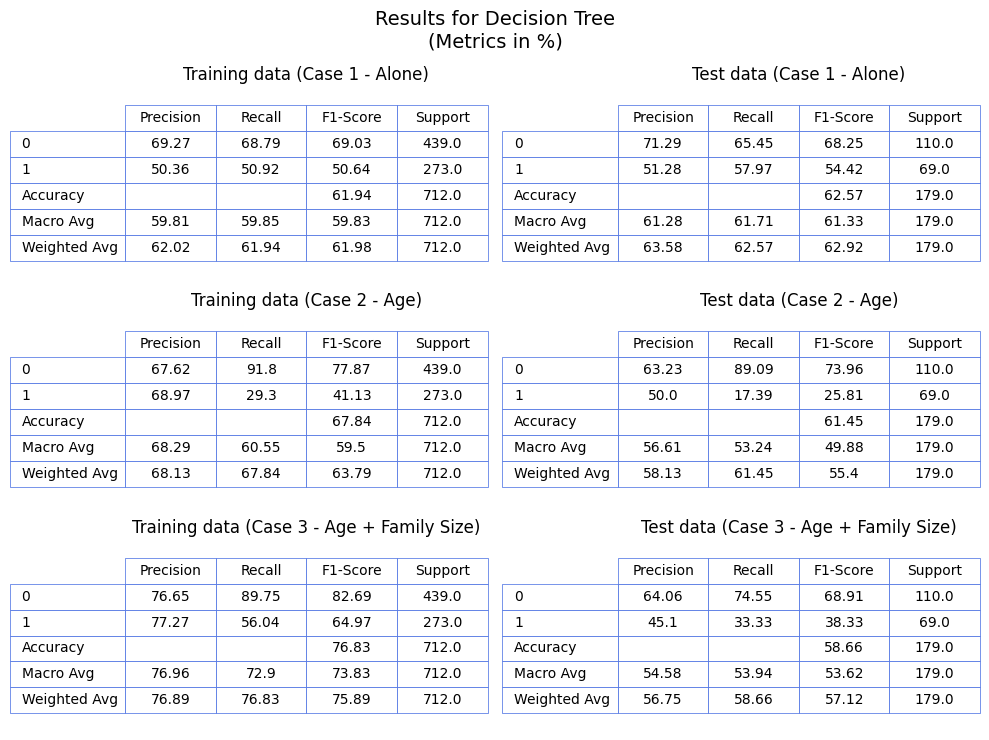

In [71]:
# Case 1: Feature = 'alone'
y1_pred = tree_model1.predict(X1_train)
y1_test_pred = tree_model1.predict(X1_test)

# Case 2: Feature = 'age'
y2_pred = tree_model2.predict(X2_train)
y2_test_pred = tree_model2.predict(X2_test)

# Case 3: Features = 'age' + 'family_size'
y3_pred = tree_model3.predict(X3_train)
y3_test_pred = tree_model3.predict(X3_test)

tree_dict1: dict = {
    "Case 1 - Alone": ((y1_train, y1_pred), (y1_test, y1_test_pred)),
    "Case 2 - Age": ((y2_train, y2_pred), (y2_test, y2_test_pred)),
    "Case 3 - Age + Family Size": ((y3_train, y3_pred), (y3_test, y3_test_pred))
}
flat_tree_dict1 = ((case, y_t, y_p) for case, data in tree_dict1.items() for y_t, y_p in data)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,7.5))

for idx, (ax, (case, y_t, y_p)) in enumerate(zip(axes.flatten(), flat_tree_dict1, strict=True)):

    classification_table(y_t, y_p, ax)
    ax.set_title(f"{"Training" if idx % 2 == 0  else "Test"} data ({case})")

fig.suptitle("Results for Decision Tree\n(Metrics in %)", size=14)
plt.tight_layout()
plt.show()
fig.savefig("tree_classification_all_cases.png")

### 4.4 Report Confusion Matrix (as a heatmap)

We then proceed to plot a confusion matrix for all cases.

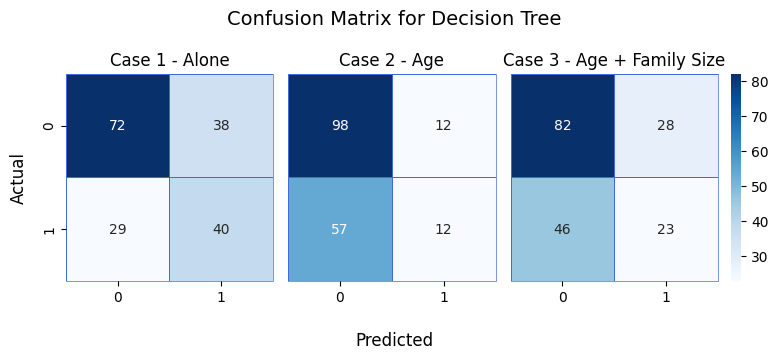

In [72]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(8,3.5), gridspec_kw={"width_ratios": [1, 1, 1.25]})

for ax, (case, (_, (y_test, y_test_pred))) in zip(axes, tree_dict1.items(), strict=True):
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", ax=ax, cbar=ax is axes[-1],
                linewidths=.5, linecolor="royalblue")
    ax.patch.set_edgecolor("royalblue")
    ax.patch.set_linewidth(0.5)
    ax.set(title=f"{case}")

for ax in axes[1:]:
    ax.set( yticks=[], ylabel="")

fig.suptitle("Confusion Matrix for Decision Tree", size=14)
fig.supxlabel("Predicted")
fig.supylabel("Actual")
plt.tight_layout()
plt.show()

### 4.5 Report Decision Tree Plot

Finally, we plot the decision tree model for each case.

In [73]:
tree_dict2: dict = {
    "Case 1 - Alone": (tree_model1, X1),
    "Case 2 - Age": (tree_model2, X2),
    "Case 3 - Age + Family Size": (tree_model3, X3)
}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(100,90))

for ax, (case, (model, feature)) in zip(axes, tree_dict2.items(), strict=True):
    plot_tree(model, feature_names=feature.columns.tolist(), ax=ax,
              class_names=["Not Survived", "Survived"], filled=True)
    ax.set_title(f"Decision Tree ({case})", size=70)

plt.tight_layout()
plt.show()
fig.savefig("tree_plot_all_cases.png")

### Reflection 4:

1) How well did the different cases perform?

    | Model Type | Case | Features Used | Accuracy | Precision | Recall | F1-Score |
    |------------|------|---------------|----------|-----------|--------|-----------|
    | Decision Tree | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
    |                   | Case 2 | age | 61.45% | 56.61% | 53.24% | 49.88% |
    |                   | Case 3 | age + family_size | 59.22% | 57.47% | 59.22% | 57.82% |

    (Weighted averages reported for Precision, Recall, and F1_Score due to significant class imbalance of the target feature (342-549))

   - Case 1: Alone

        Case 1 using only the feature 'alone' as a predictor performed the best out of all three models, with all model metrics ranging from 62.57% to 63.58%, and thus provides the most predictive power for survival out of the decision tree models.
   - Case 2: Age
    
        Case 2 using only the feature 'age' as a predictor was the weakest model of the three, with all model metrics ranging from 49.88% to 61.45%.  Precision and recall were 56.61% and 53.24% respectively, suggesting a significant decrease from the Case 1 model in identifying positive cases. 
   - Case 3: Age + Family Size

        Case 3 using both 'age' and 'family_size' as predictors produced a slightly better model than Case 2, though still significantly worse than the model for Case 1.  All model metrics ranged from 57.47% to 59.22%, with the notably lowest accuracy of the three models at 59.22%.

2) Are there any surprising results?

    The second case where 'age' was the predicting feature gave 57 false negatives, that is the model incorrectly predicted that 57 people did not survive the disaster when they actually did.  This was also reflected through the low class specific recall score of only 17.39%.
3) Which inputs worked better? 

    Overall, the 'alone' feature worked best as an input, since it had the most consistent class specific metrics between all the models.

## Section 5. Compare Alternative Models (SVC, NN)


### 5.1 Train and Evaluate Model (SVC)

Now, we will train and evaluate SVC models of varying kernels for all three cases.

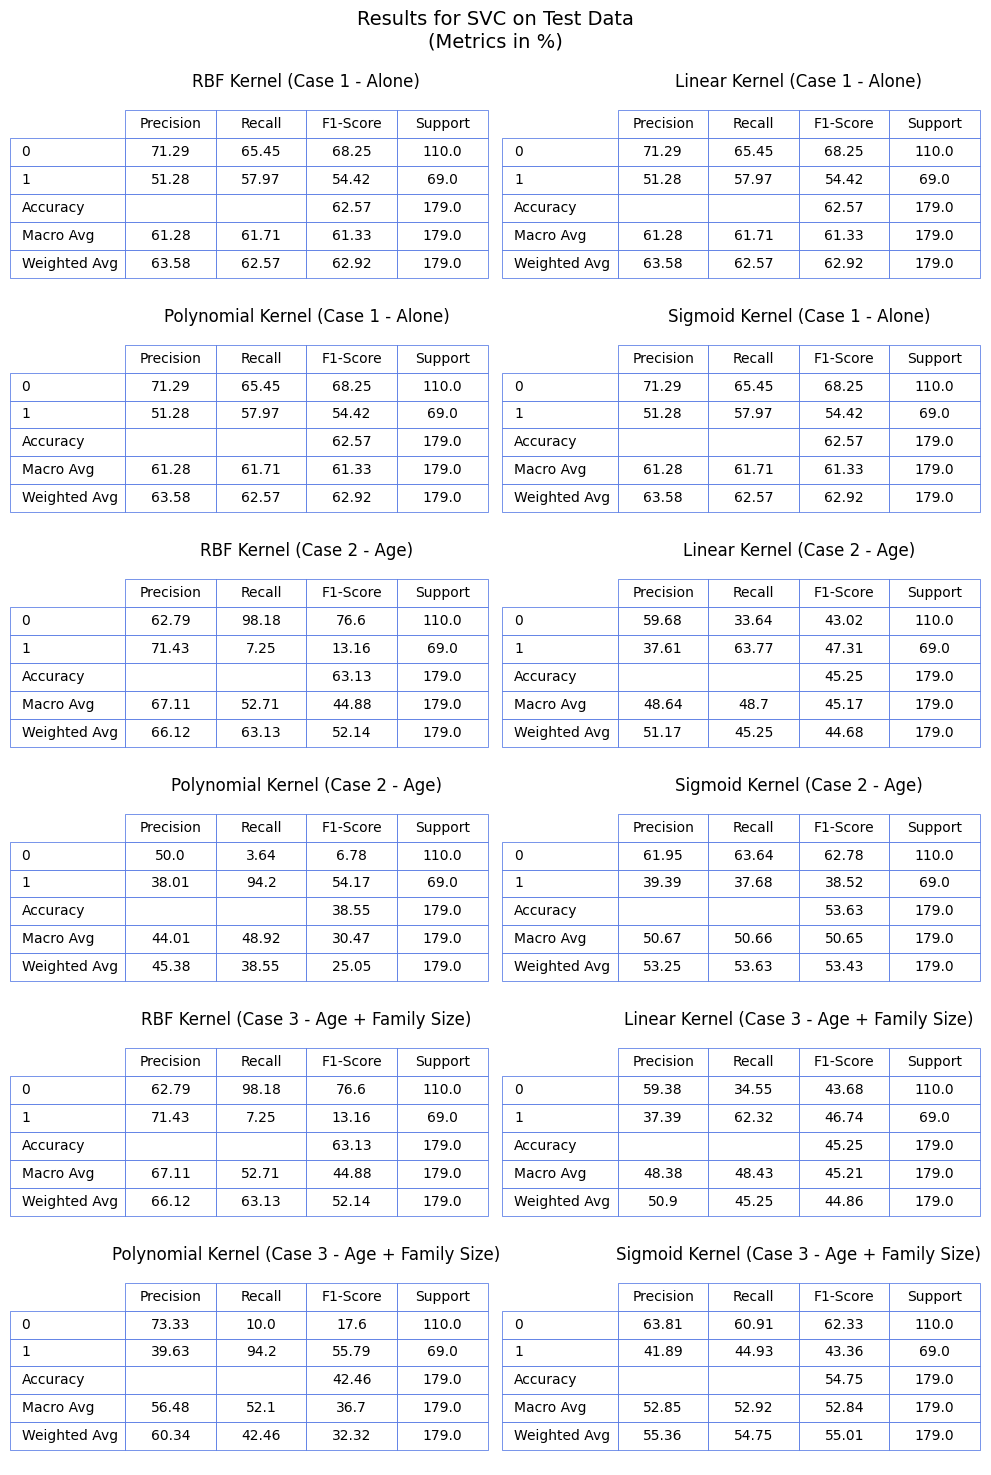

In [74]:
# CASE 1: SVC using 'alone'
svc_dict1: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear"},
    "Polynomial": {"kernel": "poly", "degree": 3},
    "Sigmoid": {"kernel": "sigmoid"}
}
# CASE 2: SVC using 'age'
svc_dict2: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear", "class_weight": "balanced"},
    "Polynomial": {"kernel": "poly", "degree": 3, "class_weight": "balanced"},
    "Sigmoid": {"kernel": "sigmoid"}
}
# CASE 3: SVC using 'age' + 'family_size'
svc_dict3: dict = {
    "RBF": {"kernel": "rbf"},
    "Linear": {"kernel": "linear", "C": 0.01, "class_weight": "balanced"},
    "Polynomial": {"kernel": "poly", "degree": 3, "C": 521.4, "class_weight": "balanced"},
    "Sigmoid": {"kernel": "sigmoid"}
}
case_train_test_svc: dict = {
    "Case 1 - Alone": ((X1_train, X1_test, y1_train, y1_test), svc_dict1),
    "Case 2 - Age": ((X2_train, X2_test, y2_train, y2_test), svc_dict2),
    "Case 3 - Age + Family Size": ((X3_train, X3_test, y3_train, y3_test), svc_dict3)
}
svc_model_dict: dict = {}
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10,15))
axes, idx = axes.flatten(), 0

for case, ((X_train, X_test, y_train, y_test), svc_dict) in case_train_test_svc.items():

    svc_model_dict[case] = {}

    for kernel, parameters in svc_dict.items():

        svc_model = SVC(**parameters)
        svc_model.fit(X_train, y_train)
        svc_model_dict[case][kernel] = svc_model
        y_svc_pred = svc_model.predict(X_test)
        classification_table(y_test, y_svc_pred, axes[idx])
        axes[idx].set_title(f"{kernel} Kernel ({case})")
        idx += 1

fig.suptitle("Results for SVC on Test Data\n(Metrics in %)\n", size=14)
plt.tight_layout()
plt.show()
fig.savefig("svc_classification_all_cases.png")

We then proceed to tune hyperparameters.

In [75]:
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

In [76]:
C_range = np.logspace(-4, 3, 100)
param_grid = {"C": C_range}

grid_search = GridSearchCV(
    estimator=SVC(kernel="poly", class_weight="balanced", random_state=42, degree=3),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X3_train, y3_train)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X3_test)

print(f"Best C value:  {grid_search.best_params_['C'].round(5)}")
print(f"Best F1 Score: {round(grid_search.best_score_, 3)}")
print(classification_report(y3_test, y_pred_best))

Best C value:  521.40083
Best F1 Score: 0.394
              precision    recall  f1-score   support

           0       0.73      0.10      0.18       110
           1       0.40      0.94      0.56        69

    accuracy                           0.42       179
   macro avg       0.56      0.52      0.37       179
weighted avg       0.60      0.42      0.32       179



### 5.2 Visualize Support Vectors

At this stage, we visualize the support vectors from our SVC models for all cases beginning with the support vectors for Case 1.

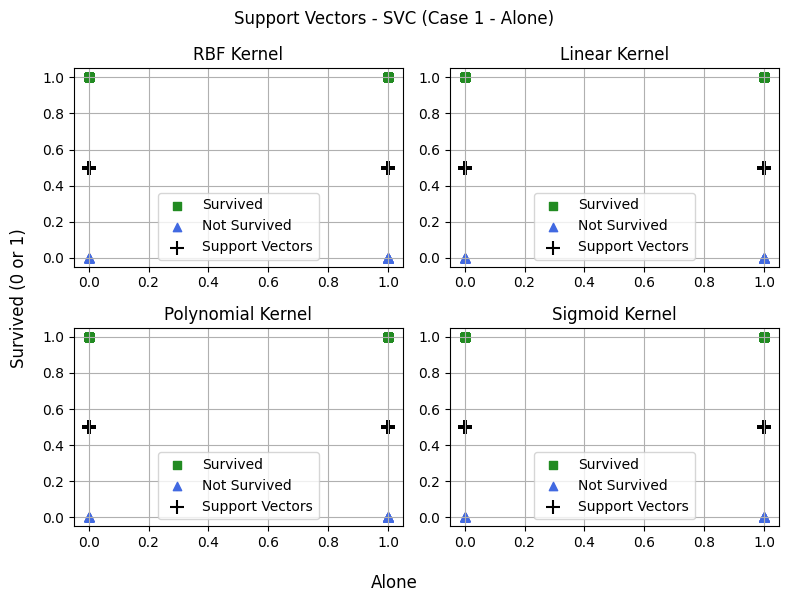

In [77]:
survived_alone = X1_test.loc[y1_test == 1, "alone"]
not_survived_alone = X1_test.loc[y1_test == 0, "alone"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

for ax, (kernel, svc_model) in zip(axes.flatten(), svc_model_dict["Case 1 - Alone"].items(), strict=True):

    ax.scatter(survived_alone, y1_test.loc[y1_test == 1], c="forestgreen", marker="s", label="Survived")
    ax.scatter(not_survived_alone, y1_test.loc[y1_test == 0], c="royalblue", marker="^", label="Not Survived")

    if hasattr(svc_model, "support_vectors_"):
        support_x = svc_model.support_vectors_[:, 0]
        ax.scatter(support_x, [0.5] * len(support_x), c="black", marker="+", s=100, label="Support Vectors")

    ax.set_title(f"{kernel} Kernel")
    ax.legend()
    ax.grid(True)

fig.suptitle("Support Vectors - SVC (Case 1 - Alone)")
fig.supxlabel("Alone")
fig.supylabel("Survived (0 or 1)")
plt.tight_layout()
plt.show()

Then, we plot the support vectors for Case 2.

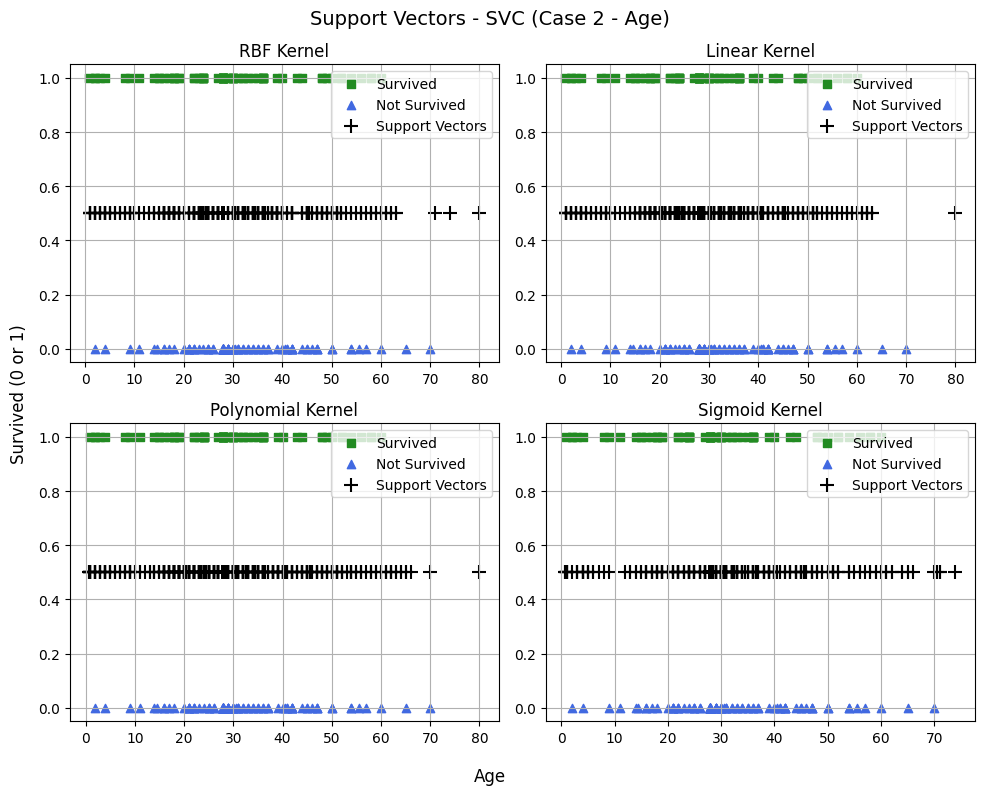

In [78]:
survived_age = X2_test.loc[y2_test == 1, "age"]
not_survived_age = X2_test.loc[y2_test == 0, "age"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for ax, (kernel, svc_model) in zip(axes.flatten(), svc_model_dict["Case 2 - Age"].items(), strict=True):

    ax.scatter(survived_age, y2_test.loc[y2_test == 1], c="forestgreen", marker="s", label="Survived")
    ax.scatter(not_survived_age, y2_test.loc[y2_test == 0], c="royalblue", marker="^", label="Not Survived")

    if hasattr(svc_model, "support_vectors_"):
        support_x = svc_model.support_vectors_[:, 0]
        ax.scatter(support_x, [0.5] * len(support_x), c="black", marker="+", s=100, label="Support Vectors")

    ax.set_title(f"{kernel} Kernel")
    ax.legend()
    ax.grid(True)

fig.suptitle("Support Vectors - SVC (Case 2 - Age)", size=14)
fig.supxlabel("Age")
fig.supylabel("Survived (0 or 1)")
plt.tight_layout()
plt.show()

Finally, we plot the support vectors for Case 3.

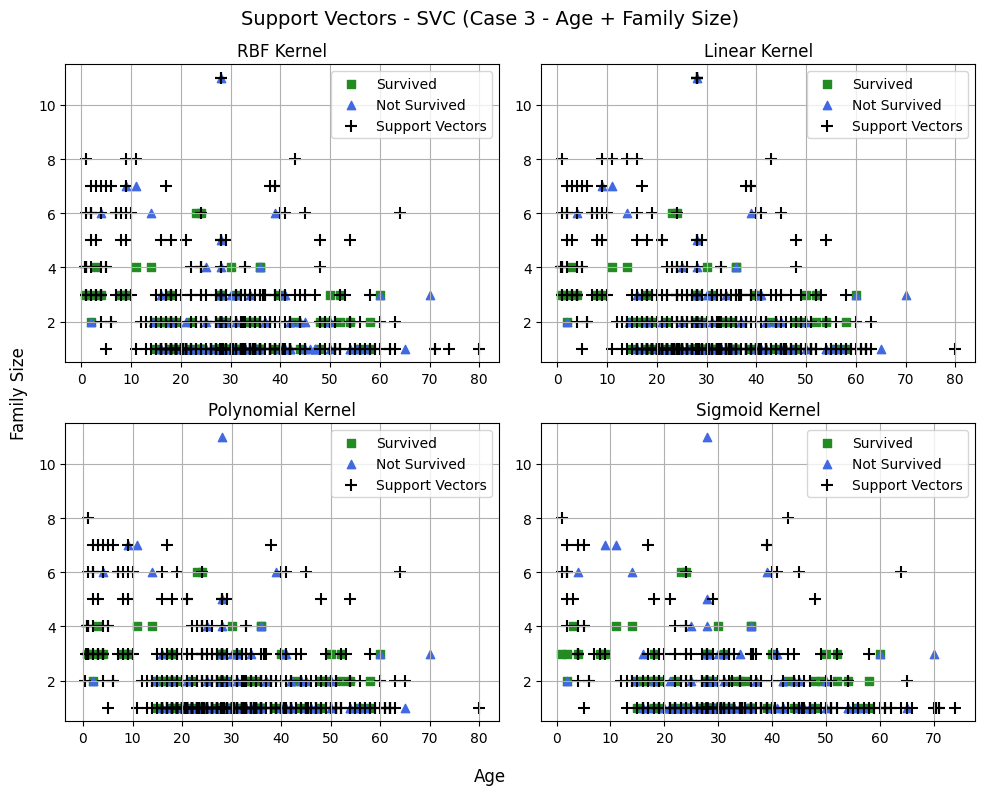

In [79]:
survived = X3_test[y3_test == 1]
not_survived = X3_test[y3_test == 0]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for ax, (kernel, svc_model) in zip(axes.flatten(), svc_model_dict["Case 3 - Age + Family Size"].items(), strict=True):

    ax.scatter(survived["age"], survived["family_size"],
            c="forestgreen", marker="s", label="Survived")
    ax.scatter(not_survived["age"], not_survived["family_size"],
            c="royalblue", marker="^", label="Not Survived")

    if hasattr(svc_model, "support_vectors_"):
        support_vectors = svc_model.support_vectors_
        ax.scatter(support_vectors[:, 0], support_vectors[:, 1],
                    c="black", marker="+", s=75, label="Support Vectors")

    ax.set_title(f"{kernel} Kernel")
    ax.legend()
    ax.grid(True)

fig.suptitle("Support Vectors - SVC (Case 3 - Age + Family Size)", size=14)
fig.supxlabel("Age")
fig.supylabel("Family Size")
plt.tight_layout()
plt.show()

### 5.3 Train and Evaluate Model (Neural Network on Case 3)

Now, we'll train a Neural Network (Multi-Layer Perceptron) classifier using age and family_size as input features.

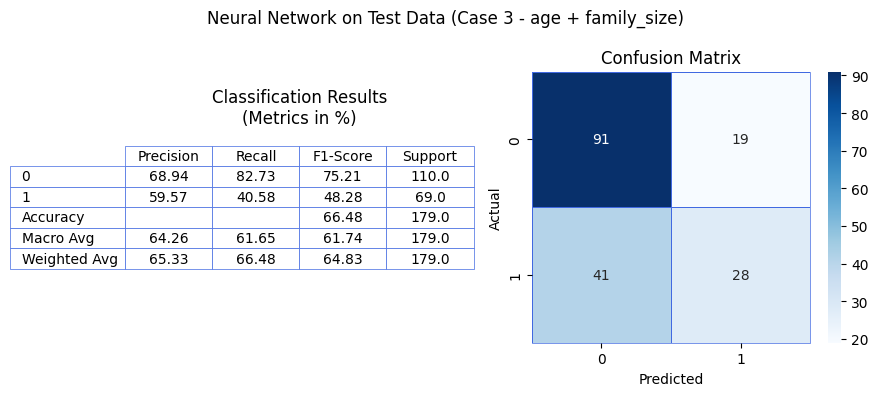

In [80]:
nn_model3 = MLPClassifier(
    hidden_layer_sizes=(50, 25, 10),
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
nn_model3.fit(X3_train, y3_train)
y3_nn_pred = nn_model3.predict(X3_test)

fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize=(9, 4))

classification_table(y3_test, y3_nn_pred, axes[0])
axes[0].set_title("Classification Results\n(Metrics in %)", y=0.78)

cm_nn3 = confusion_matrix(y3_test, y3_nn_pred)
sns.heatmap(cm_nn3, annot=True, cmap="Blues", ax=axes[1],
                  linewidths=.5, linecolor="royalblue")
axes[1].patch.set_edgecolor("royalblue")
axes[1].patch.set_linewidth(0.5)
axes[1].set(xlabel="Predicted", ylabel="Actual", title="Confusion Matrix")

fig.suptitle("Neural Network on Test Data (Case 3 - age + family_size)")
plt.tight_layout()
plt.show()
fig.savefig("nn_classification_age_familysize.png", bbox_inches="tight")

### 5.4 Visualize (Neural Network on Case 3)

Now, we visualize the learned decision boundary along with our target classes to gain insight on how our model predicts across our input features.

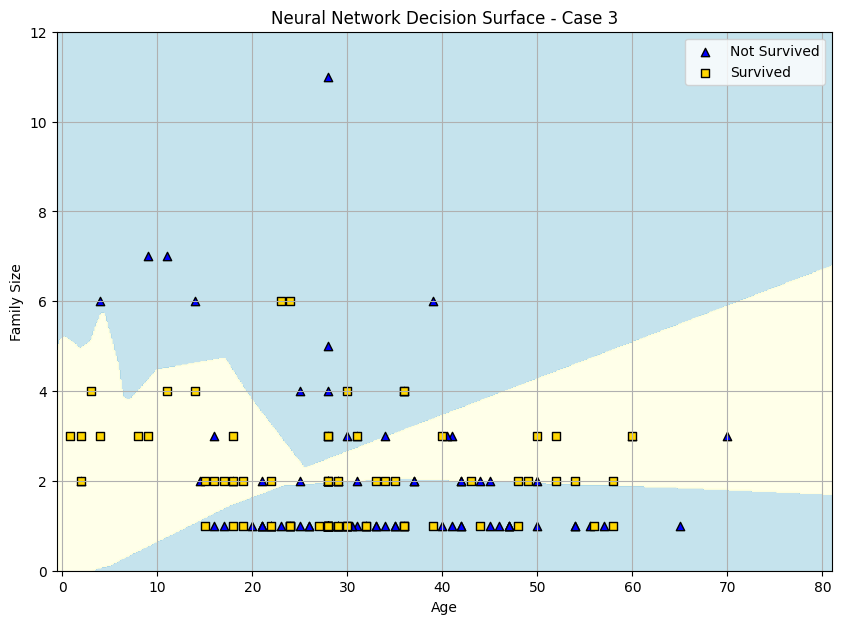

In [81]:
padding = 1
x_min, x_max = X3["age"].min() - padding, X3["age"].max() + padding
y_min, y_max = X3["family_size"].min() - padding, X3["family_size"].max() + padding
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                                    np.linspace(y_min, y_max, 500))

Z = nn_model3.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["age", "family_size"]))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
cmap_background = ListedColormap(["lightblue", "lightyellow"])

plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.7)
plt.scatter(X3_test["age"][y3_test == 0],
            X3_test["family_size"][y3_test == 0],
            c="blue", marker="^", edgecolor="k", label="Not Survived")
plt.scatter(X3_test["age"][y3_test == 1],
            X3_test["family_size"][y3_test == 1],
            c="gold", marker="s", edgecolor="k", label="Survived")

plt.gca().set(xlabel="Age", ylabel="Family Size", title="Neural Network Decision Surface - Case 3")
plt.legend()
plt.grid(True)
plt.show()

At this point, we tune hyperparameters.

In [82]:
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

smote = SMOTE(random_state=42)
X3_train_bal, y3_train_bal = smote.fit_resample(X3_train_scaled, y3_train)

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Best parameters found: {'activation': 'relu', 'alpha': np.float64(0.000774263682681127), 'batch_size': 64, 'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV score: 0.6327729222823641


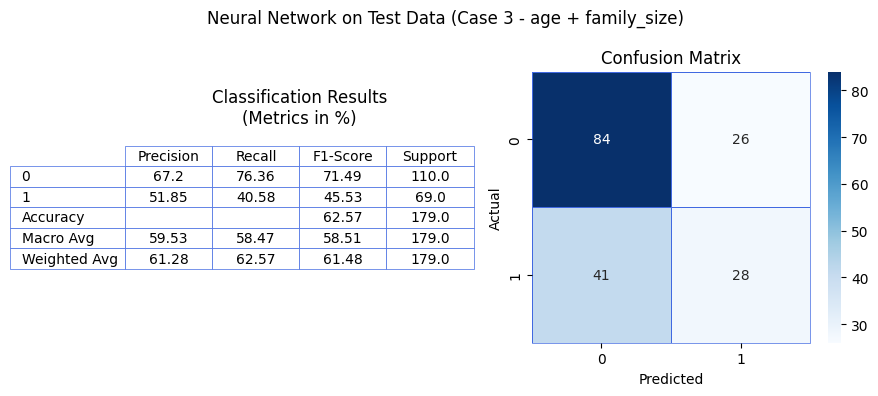

In [84]:
# CAUTION: Long run time!

nn_model_tune = MLPClassifier(
    max_iter=1000,
    random_state=42
)

parameter_space = {
    "hidden_layer_sizes": [(20,), (50,), (100,), (20,10), (50, 25), (100, 50), (50, 25, 10), (20, 10, 5)],
    "activation": ["tanh", "relu"],
    "solver": ["adam"],
    "alpha": np.logspace(-4,0,10),
    "learning_rate_init": [0.001, 0.01, .1],
    "batch_size": [32, 64, 128]
}

clf = GridSearchCV(nn_model_tune, parameter_space, n_jobs=-1, cv=5, verbose=1, scoring="f1_weighted")
clf.fit(X3_train, y3_train) #bal

best_model = clf.best_estimator_
print("Best parameters found:", clf.best_params_)
print("Best CV score:", clf.best_score_)

y3_best_pred = best_model.predict(X3_test)

fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize=(9, 4))

classification_table(y3_test, y3_best_pred, axes[0])
axes[0].set_title("Classification Results\n(Metrics in %)", y=0.78)

cm_nn3 = confusion_matrix(y3_test, y3_best_pred)
sns.heatmap(cm_nn3, annot=True, cmap="Blues", ax=axes[1],
                  linewidths=.5, linecolor="royalblue")
axes[1].patch.set_edgecolor("royalblue")
axes[1].patch.set_linewidth(0.5)
axes[1].set(xlabel="Predicted", ylabel="Actual", title="Confusion Matrix")

fig.suptitle("Neural Network on Test Data (Case 3 - age + family_size)")
plt.tight_layout()
plt.show()

### Reflection 5:
1) How well did each of these new models/cases perform?

    Overall, the model trained with the neural network performed better than the SVC trained models.  The accuracy and weighted average metrics ranged from 64.83% to 66.48% for the neural network on Case 3, contrast to 52.14% to 66.12% for the RBF kernel of the SVC model for Case 3.

    
2) Are there any surprising results or insights?

    The neural network had a disproportionate recall, 82.73% for non-survivors and 40.58% for survivors, indicating the model was struggling to identify survivors. This is likely due to the class imbalance of the target feature of the dataset, where we had 549 non-survivors versus 342 survivors. 

3) Why might one model outperform the others?

    SVC models may outperform Neural Network on small to medium size datasets, especially those with relatively high feature to sample ratio where they are known to accel at maximizing margins.  While the neural networks hierarchical feature learning through layers tends to perform better on larger datasets with a lower feature to sample ratio to avoid overfitting during parameter tuning.

## Section 6. Final Thoughts & Insights


- Findings Summary:

| Model Type | Case | Features Used | Accuracy | Precision | Recall | F1-Score |
|------------|------|---------------|----------|-----------|--------|-----------|
| Decision Tree | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                   | Case 2 | age | 61.45% | 56.61% | 53.24% | 49.88% |
|                   | Case 3 | age + family_size | 59.22% | 57.47% | 59.22% | 57.82% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (RBF Kernel)| Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 63.13% | 66.12% | 63.13% | 52.14% |
|                    | Case 3 | age + family_size | 63.13% | 66.12% | 63.13% | 52.14% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Linear Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 45.25% | 51.17% | 45.25% | 44.68% |
|                    | Case 3 | age + family_size | 45.25% | 50.90% | 45.25% | 44.86% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Poly Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 38.55% | 45.38% | 38.55% | 25.05% |
|                    | Case 3 | age + family_size | 42.46% | 60.34% | 42.46% | 32.32% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Sigmoid Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 53.63% | 53.25% | 53.63% | 53.43% |
|                    | Case 3 | age + family_size | 54.75% | 55.36% | 54.75% | 55.01% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| Neural Network (MLP) | Case 3 | age + family_size | 66.48% | 65.33% | 66.48% | 64.83% |

(Weighted averages reported for Precision, Recall, and F1_Score due to significant class imbalance of the target feature (342-549))

- Challenges faced:

    The overall workflow went smooth overall, with the only drawback being the amount of time to process hyperparameter tuning runs.

- Next steps to gain more insights and/or to explore classification models:

    Going forward, training models on more input features and tuning hyperparameters of the current models should prove beneficial in gaining more insights of the dataset. Training neural networks with a different API could also prove more efficient and possibly yield stronger performance due to GPU utilization.